# Introduction to Developing AI Agents

## Understanding Fundamental Concepts of AI Agents

This notebook covers what AI agents are, the five main types of agents,
and two hands-on demos using **LangGraph** and **CrewAI** — two of the most
popular frameworks for building agentic systems today.


### 📚 What You Will Learn

**Part 1 — Theory: Types of AI Agents**
- What is an AI agent and how it perceives and acts in its environment
- The five main types of AI agents (from simple rules to learning systems)
- What makes modern LLM-based agents different from classical agents
- Key design patterns used in production agentic systems

**Part 2 — Hands-on Demo: LangGraph**
- Build a simple conversational agent with LangGraph
- Add tools (functions the agent can call) to answer real-world questions
- Implement a multi-agent system with a supervisor coordinating specialist agents

> **Prerequisites:** Basic Python knowledge. No prior AI/ML experience required.


---

## 🤖 What is an AI Agent?

> *"An agent is anything that can perceive its environment and act upon that environment."*
> — Russell & Norvig, Artificial Intelligence: A Modern Approach

An AI agent is a program that:
1. **Perceives** its environment through inputs (text, data, sensor readings)
2. **Reasons** about what to do next
3. **Acts** to achieve a goal
4. **Repeats** this loop continuously

### The PEAS Framework

Every agent can be described using four dimensions:

| PEAS | Meaning | Example (shop assistant agent) |
|---|---|---|
| **P**erformance | How we measure success | Customer query answered correctly |
| **E**nvironment | Where the agent operates | Customer chat interface |
| **A**ctuators | How the agent acts | Sends a text reply |
| **S**ensors | How the agent perceives | Reads the customer's message |

### What makes an agent *rational*?

A **rational agent** chooses the action most likely to maximise its performance measure,
given what it knows about the environment. It doesn't need to be perfect —
it just needs to make the best decision it can with the information available.


<div style="text-align: center;">
  <img src="assets/01-the-core-components-of-an-AI-agent.png" alt="My image" width="640">
</div>

---

## 1. Simple Reflex Agent

Simple reflex agents make decisions based **only on current percepts**, ignoring history.

**Characteristics:**
- Operate only in **fully observable environments**
- Follow **condition-action rules** (if *this*, then *that*)

**Limitations:**
- Limited intelligence — no memory of past states
- No knowledge of non-perceptual aspects of the environment
- Rule tables are often too large to generate or store
- Not adaptive to environmental changes

**Examples:**
- Basic spam filters
- Automated email responders

<div style="text-align: center;">
  <img src="assets/02-simple-reflex-agent.png" alt="Simple Reflex Agent" width="400">
</div>

---

## 2. Model-based Reflex Agent

Model-based agents work in **partially observable environments** by maintaining an internal state to track the world.

**Two key factors:**
- **Model:** Knowledge of how the world works
- **Internal State:** Representation of the current state based on percept history

**Updating state requires knowing:**
- How the world evolves independently of the agent
- How the agent's own actions affect the world

**Examples:**
- Advanced chess AI engines
- Route optimization systems

<div style="text-align: center;">
  <img src="assets/03-model-based-reflex-agent.png" alt="Model-based Reflex Agent" width="400">
</div>

---

## 3. Goal-based Agent

Goal-based agents extend model-based agents by considering **future states** and choosing actions that lead to desired goals.

**Characteristics:**
- Maintain an internal model of the world
- Use **goal information** to decide which actions to take
- Evaluate sequences of actions rather than just reacting
- More flexible than reflex agents — behavior can change by updating the goal

**Limitations:**
- Decision-making can be computationally expensive
- Requires explicit goal definition

**Examples:**
- GPS navigation systems
- Robot path planners

<div style="text-align: center;">
  <img src="assets/04-goal-based-agent.png" alt="Goal-based Agent" width="400">
</div>

---

## 4. Learning Agent

Learning agents **improve over time** by learning from past experiences and feedback.

**Four main components:**
- **Learning Element:** Improves performance by interacting with the environment
- **Critic:** Provides feedback on how well the agent is performing
- **Performance Element:** Selects external actions based on current knowledge
- **Problem Generator:** Suggests exploratory actions to discover new experiences

**Examples:**
- Content recommendation systems (Netflix, Spotify)
- Adaptive thermostat systems

<div style="text-align: center;">
  <img src="assets/05-learning-agent.png" alt="Learning Agent" width="400">
</div>

---

## 5. Advanced AI Agents

Advanced AI agents leverage **Large Language Models (LLMs)** as a reasoning engine to plan and execute complex, multi-step tasks.

**Key capabilities:**
- Use an LLM to reason, plan, and decide which actions to take
- Interact with **external tools** (APIs, databases, search engines)
- Maintain **memory** across interactions (short-term and long-term)
- Support **multi-agent collaboration** — multiple agents working together
- Operate in dynamic, open-ended environments

**Key components:**
- **LLM Core:** The reasoning and language understanding backbone
- **Tools:** Functions or APIs the agent can call
- **Memory:** Storage of past interactions and state
- **Planning:** Breaking down complex goals into executable steps

**Examples:**
- LangGraph-based shop hours inquiry system
- CrewAI returns and refunds assistant

<div style="text-align: center;">
  <img src="assets/06-key-components -of-advanced-AI-agents.png" alt="Key Components of Advanced AI Agents" width="640">
</div>

### The Spectrum of Agentic Systems

"Agentic" is not a binary — it is a spectrum. Systems become more agentic as they
gain more autonomy, adaptability, and goal-directed behaviour.

| ← Less Agentic | | | | | More Agentic → |
|---|---|---|---|---|---|
| Hard-coded rules | Rule-based systems | ML models | Adaptive AI | LLM-powered agents | Fully autonomous |
| `if X: do Y` | Decision trees | Classifiers | Reinforcement learning | GPT + tools | Self-directed systems |

The demos in this notebook sit towards the **right side** — LLM-powered agents
that reason, use tools, and collaborate.


### Agentic AI Design Patterns

Modern LLM-based agents are built from a small set of composable patterns.
Understanding these helps you design better agentic systems.

| Pattern | What it means | Example |
|---|---|---|
| **Reflection** | The agent critiques its own output and improves it | Write → review → rewrite |
| **Tool use** | The agent calls external functions to get real data | Check current time, search the web |
| **Planning** | The agent breaks a complex goal into sub-steps | Research → draft → edit → publish |
| **Multi-agent** | Multiple agents collaborate, each with a specialised role | Supervisor + researcher + writer |
| **Memory** | The agent stores and retrieves past context | Remember previous conversation turns |

> **Note:** These patterns can be combined. The demos in this notebook use
> **tool use**, **planning**, and **multi-agent** patterns.


---

# Introduction to LangGraph

[LangGraph](https://langchain-ai.github.io/langgraph/) is an open-source framework
by LangChain for building **stateful, controllable AI agents**.

Unlike simple LLM calls (prompt → response), LangGraph lets you define
**graphs** where:
- Each **node** is a function (an agent step, a tool call, a decision)
- Each **edge** controls which node runs next
- A **state** object is passed between nodes so agents can remember context

This gives you fine-grained control over how your agent reasons and acts —
which is why it is widely used in production AI systems.

### Why LangGraph instead of a plain LLM call?

| Plain LLM call | LangGraph agent |
|---|---|
| Single prompt → single response | Multi-step reasoning loop |
| No memory between calls | Persistent state across steps |
| Cannot call tools | Can call any Python function |
| No branching logic | Conditional edges, routing |


<div style="text-align: center;">
  <img src="assets/07-craved-rock-fitness-shoes-company.png" alt="Craved Rock Fitness Shoes Company" width="720">
</div>

## Using LangGraph with Tool Calling to Create Agentic Workflow for Shop Hours Inquiry

- LangGraph introduced by LangChain
- With LangGraph you can create highly controllable agents

### LangGraph's Key Components

- **State:** A shared data structure that represents the current snapshot
- **Nodes:** Functions that encode the logic of your agents
- **Edges:** Functions that determine which Node to execute next

---

**References**

- 📖 [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- 📖 [LangGraph Python API Reference](https://langchain-ai.github.io/langgraph/reference/)


In [1]:
%pip install -q -U langchain_openai langchain_core langgraph langgraph-supervisor python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads OPENAI_API_KEY from .env

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not set — add it to your .env file"

### Step 1 — A Simple Conversational Agent

Let's build the simplest possible LangGraph agent: one that takes a message
and returns a reply. This establishes the three core concepts before we add complexity.

**The graph we are building:**
```
START → assistant → END
```

- `START` — the entry point (LangGraph built-in)
- `assistant` — our node: calls the LLM and returns the response
- `END` — terminates the graph (LangGraph built-in)

**`MessagesState`** is a built-in state type that stores a list of messages
(the conversation history). Every node receives this state and returns updates to it.


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [4]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="You are a helpful assistant. Answer questions clearly and concisely.")

def assistant(state: MessagesState) -> dict:
    return {"messages": [llm.invoke([sys_msg] + state["messages"])]}

#### Building and Visualising the Graph

We now wire the node into a graph using `StateGraph`, compile it,
and visualise it. The diagram confirms our simple `START → assistant → END` structure.


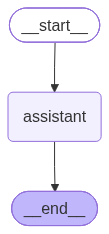

In [5]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)

react_graph = builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))

#### Running the Agent

We call `react_graph.invoke(...)` with a `HumanMessage` and print all
messages in the conversation. You should see the question followed by
the LLM's answer.


In [6]:
messages = react_graph.invoke({"messages": [HumanMessage(content="What is the capital of Sweden?")]})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the capital of Sweden?
================================== Ai Message ==================================

The capital of Sweden is Stockholm.


---

### Step 2 — Adding Tools (The ReAct Pattern)

A plain LLM cannot answer *"Is the shop open right now?"* — it has no access
to real-time data. We solve this with **tools**: Python functions the agent
can call to get live information.

This is the **ReAct** pattern (Reason + Act):
1. LLM **reasons** about what it needs
2. LLM **acts** by calling a tool
3. Tool result is added to the conversation
4. LLM **reasons** again with the new information
5. Repeat until the LLM has enough to answer

We define two tools:
- `shop_opening_hours()` — returns the weekly schedule
- `current_time()` — returns today's date and time

> **Why upgrade to `gpt-4o`?** Tool calling requires the model to generate
> structured JSON to invoke functions reliably. `gpt-4o` does this more
> consistently than `gpt-4o-mini`.


In [7]:
import datetime

# Upgrade to gpt-4o for reliable tool-calling
llm = ChatOpenAI(model="gpt-4o", temperature=0)

def shop_opening_hours() -> str:
    """Returns the weekly opening hours schedule for the shop."""
    return (
        "Monday-Friday: 10:00am - 8:00pm\n"
        "Saturday:      11:00am - 5:00pm\n"
        "Sunday:         1:00pm - 6:00pm"
    )

def current_time() -> str:
    """Returns the current date and time as a formatted string."""
    return datetime.datetime.now().strftime("%A, %Y-%m-%d %H:%M:%S")


#### Binding Tools to the LLM

`llm.bind_tools(tools)` tells the LLM which functions it can call.
The LLM will now include tool call requests in its response when it needs
to fetch data — instead of (incorrectly) making up an answer.


In [8]:
tools = [shop_opening_hours, current_time]

llm_with_tools = llm.bind_tools(tools)


#### Updating the Assistant Node

We redefine the `assistant` node to use `llm_with_tools` (the tool-aware LLM)
and give it a clearer system prompt describing its job.


In [9]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

sys_msg = SystemMessage(content=(
    "You are a helpful assistant responsible for determining whether a shop is open or closed. "
    "Use the available tools to get the current time and the shop's opening schedule, "
    "then give a clear yes/no answer with the relevant details."
))

def assistant(state: MessagesState) -> dict:
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


#### Building the Tool-Calling Graph

The new graph has an extra node: **`tools`**. The `tools_condition` edge checks
whether the LLM wants to call a tool. If yes, it routes to `tools`; if no,
the conversation ends.

```
START → assistant ──(needs tool?)──► tools → assistant (loop)
                  └──(done)──────► END
```

`ToolNode` automatically finds the right Python function for each tool call
and adds the result back into the message state.


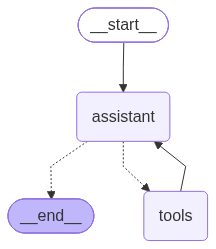

In [10]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))


#### Running the Tool-Calling Agent

Ask the agent whether the shop is open. Watch how it automatically calls
both `shop_opening_hours` and `current_time` before reasoning about the answer.


In [11]:
messages = [HumanMessage(content="Tell me if the shop is open right now")]
messages = react_graph.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Tell me if the shop is open right now
================================== Ai Message ==================================
Tool Calls:
  current_time (call_WFbCyqgWYYkFK0FlzXhw6pNL)
 Call ID: call_WFbCyqgWYYkFK0FlzXhw6pNL
  Args:
  shop_opening_hours (call_HojfxfI4CorHQDlKudLdHTd6)
 Call ID: call_HojfxfI4CorHQDlKudLdHTd6
  Args:
================================= Tool Message =================================
Name: current_time

Monday, 2026-09-07 20:37:45
================================= Tool Message =================================
Name: shop_opening_hours

Monday-Friday: 10:00am - 8:00pm
Saturday:      11:00am - 5:00pm
Sunday:         1:00pm - 6:00pm
================================== Ai Message ==================================

The current time is Monday, September 7, 2026, at 8:37 PM. According to the shop's schedule, it is open Monday to Friday from 10:00 AM to 8:00 PM. Since it is currently 8:37 PM,

---

## Implementing LangGraph Multi Agent Supervisor for Shop Hours Inquiry

### What is a Multi-Agent System?

Instead of one agent doing everything, we split work between **specialist agents**
and a **supervisor** that coordinates them.

**Why is this useful?**
- Each agent focuses on one thing — it does it better
- Agents can run in parallel — faster results
- Easier to debug — you know exactly which agent made a mistake
- Easier to extend — add a new agent without touching the others

### Our multi-agent setup:

| Agent | Speciality | Tool |
|---|---|---|
| `time_keeper_agent` | Knows the current date and time | `current_datetime()` |
| `schedule_keeper_agent` | Knows the shop's opening hours | `shop_opening_hours()` |
| **Supervisor** | Coordinates both agents and forms the final answer | *(none — uses sub-agents)* |

The supervisor receives the user question, decides which agents to call
(and in what order), collects their responses, and writes the final answer.


#### Defining the Sub-Agents

`create_react_agent` creates a ReAct agent in a single line — no need to build
a full graph manually. Each agent gets:
- `model` — the LLM to use
- `tools` — the functions it can call
- `name` — used by the supervisor to identify it
- `prompt` — instructions that scope its behaviour

We also redefine `current_datetime()` here to return the day of the week,
which is needed to match against the opening hours schedule.


In [12]:
import warnings
from langgraph.prebuilt import create_react_agent

warnings.filterwarnings('ignore', message='create_react_agent has been moved')

def current_datetime() -> str:
    """Returns the current date, time and day of the week."""
    dt = datetime.datetime.now()
    return f"Current datetime: {dt} ({dt.strftime('%A')})"

time_keeper_agent = create_react_agent(
    model=llm,
    tools=[current_datetime],
    name='time_keeper_agent',
    prompt='You provide the current date, time and day of the week.'
)

schedule_keeper_agent = create_react_agent(
    model=llm,
    tools=[shop_opening_hours],
    name='schedule_keeper_agent',
    prompt='You provide the shop opening hours for each day of the week.'
)


#### Installing the Supervisor Package

`langgraph-supervisor` is a separate package that provides the `create_supervisor`
helper — it handles the routing logic between the supervisor and sub-agents for you.


In [13]:
%pip install -q -U langgraph-supervisor

Note: you may need to restart the kernel to use updated packages.


#### Creating the Supervisor

`create_supervisor` wires the sub-agents into a graph where the supervisor LLM
decides who to call. `output_mode="full_history"` means we get the entire
conversation — including each agent's individual steps — in the output.


In [14]:
from langgraph_supervisor import create_supervisor

prompt = (
    "You are a team supervisor managing time_keeper_agent and schedule_keeper_agent. "
    "Your job is to respond to shop opening hour queries. "
    "Use time_keeper_agent to get the current time and date, "
    "and schedule_keeper_agent to get the shop's operating hours. "
    "You can use both agents in parallel to gather the required information."
)

workflow = create_supervisor(
    [schedule_keeper_agent, time_keeper_agent],
    model=llm,
    output_mode="full_history",
    prompt=prompt,
)


#### Running the Multi-Agent System

We compile the workflow, then invoke it with a question that requires
both agents — weekend hours *and* whether it's open right now.
Watch how the supervisor orchestrates the agents and synthesises their answers.


In [15]:
app = workflow.compile()
result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What are the shop's opening hours on the weekend? Is the shop open right now?"
        }
    ]
})

for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What are the shop's opening hours on the weekend? Is the shop open right now?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_schedule_keeper_agent (call_OuVqbgXoGDDc7UqaBtDvv6Xe)
 Call ID: call_OuVqbgXoGDDc7UqaBtDvv6Xe
  Args:
================================= Tool Message =================================
Name: transfer_to_schedule_keeper_agent

Successfully transferred to schedule_keeper_agent
================================== Ai Message ==================================
Name: schedule_keeper_agent
Tool Calls:
  shop_opening_hours (call_iMMNXB2yAW8D29DrHzQDpOvk)
 Call ID: call_iMMNXB2yAW8D29DrHzQDpOvk
  Args:
================================= Tool Message =================================
Name: shop_opening_hours

Monday-Friday: 10:00am - 8:00pm
Saturday:      11:00am - 5:00pm
Sunday:         1:00pm - 6:00pm
=================

---

## Further Reading

### LangGraph Supervisor (Multi-Agent Orchestrator)

- 📖 [LangGraph Supervisor Documentation](https://langchain-ai.github.io/langgraph/concepts/multi_agent/)
- 📦 [langgraph-supervisor PyPI package](https://pypi.org/project/langgraph-supervisor/)

### Research Papers

- 📄 [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629) — Yao et al., 2022
